## 4. TabPFN Analysis

This notebook investigates TabPFN's behavior under varying dataset sizes (Sub-question 2) and missing data rates (Sub-question 3). A common assumption in the literature is that TabPFN only works well on small datasets — this experiment tests that claim directly.

### Setup

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import shutil
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import roc_auc_score
from autogluon.tabular import TabularPredictor
from tabpfn_client import TabPFNClassifier as CloudTabPFN, init
from utils import load_and_preprocess, get_train_test_split, introduce_missing_values

init()  
os.makedirs('figures', exist_ok=True)
SEEDS = [0, 1, 2, 3, 4]
plt.rcParams['font.size'] = 12
print('Setup complete!')

Setup complete!


### Data Loading

In [2]:
_, X_auto, y = load_and_preprocess('Churn_Modelling.csv')
print(f'Features: {X_auto.shape[1]}, Samples: {X_auto.shape[0]}')

Features: 10, Samples: 10000


### Dataset Size Experiment (Sub-question 2)
Evaluate TabPFN and AutoGluon on training subsets of increasing size using a fixed test set of 2,000 samples. The maximum training size is 8,000 samples (80% of the dataset).

In [3]:
dataset_sizes = [1000, 2000, 4000, 6000, 8000]
size_results = []

X_train_full, X_test, y_train_full, y_test = get_train_test_split(X_auto, y, seed=0)

for size in dataset_sizes:
    tabpfn_aucs, auto_aucs = [], []
    for seed in SEEDS:
        X_train_sub = X_train_full.sample(n=min(size, len(X_train_full)), random_state=seed)
        y_train_sub = y_train_full[X_train_sub.index]

        # TabPFN
        clf = CloudTabPFN(random_state=seed)
        clf.fit(X_train_sub, y_train_sub)
        tabpfn_aucs.append(roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1]))

        # AutoGluon
        train_data = X_train_sub.copy()
        train_data['Exited'] = y_train_sub.values
        save_path = f'agmodels/size_{size}_seed_{seed}'
        if os.path.exists(save_path): shutil.rmtree(save_path)
        predictor = TabularPredictor(label='Exited', path=save_path, verbosity=0)
        predictor.fit(train_data, time_limit=60, presets='medium_quality')
        auto_aucs.append(roc_auc_score(y_test, predictor.predict_proba(X_test)[1]))
        shutil.rmtree(save_path)

    size_results.append({
        'size': size,
        'tabpfn_auc_mean': np.mean(tabpfn_aucs), 'tabpfn_auc_std': np.std(tabpfn_aucs),
        'auto_auc_mean': np.mean(auto_aucs), 'auto_auc_std': np.std(auto_aucs)
    })
    print(f'Size {size}: TabPFN={np.mean(tabpfn_aucs):.4f}, AutoGluon={np.mean(auto_aucs):.4f}')

size_df = pd.DataFrame(size_results)

00:03 Fitting... Done!
00:05 Predicting... Done!
00:03 Fitting... Done!
00:06 Predicting... Done!
00:15 Fitting... Done!
00:07 Predicting... Done!
00:22 Fitting... Done!
00:07 Predicting... Done!
00:22 Fitting... Done!
01:36 Predicting... Done!
Size 1000: TabPFN=0.8563, AutoGluon=0.8234
00:05 Fitting... Done!
00:23 Predicting... Done!
00:04 Fitting... Done!
00:05 Predicting... Done!
00:36 Fitting... Done!
00:06 Predicting... Done!
00:12 Fitting... Done!
00:06 Predicting... Done!
00:06 Fitting... Done!
00:28 Predicting... Done!
Size 2000: TabPFN=0.8608, AutoGluon=0.8387
00:12 Fitting... Done!
00:05 Predicting... Done!
00:25 Fitting... Done!
00:20 Predicting... Done!
00:05 Fitting... Done!
00:20 Predicting... Done!
00:04 Fitting... Done!
00:37 Predicting... Done!
00:07 Fitting... Done!
00:06 Predicting... Done!
Size 4000: TabPFN=0.8655, AutoGluon=0.8529
00:17 Fitting... Done!
00:05 Predicting... Done!
00:02 Fitting... Done!
00:26 Predicting... Done!
00:21 Fitting... Done!
01:02 Predictin

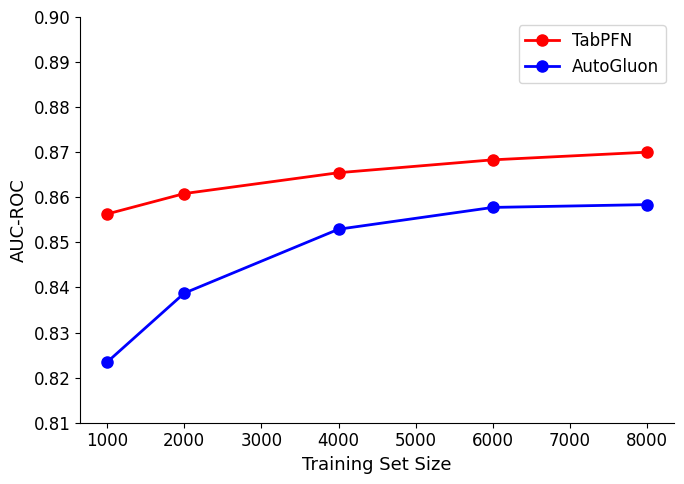

In [5]:
# Figure 9: Dataset Size
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(size_df['size'], size_df['tabpfn_auc_mean'],
        color='red', marker='o', linewidth=2, markersize=8, label='TabPFN')
ax.plot(size_df['size'], size_df['auto_auc_mean'],
        color='blue', marker='o', linewidth=2, markersize=8, label='AutoGluon')
ax.set_xlabel('Training Set Size', fontsize=13)
ax.set_ylabel('AUC-ROC', fontsize=13)
ax.set_ylim(0.81, 0.90)
ax.tick_params(labelsize=12)
ax.legend(fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('figures/figure9_dataset_size.png', dpi=150, bbox_inches='tight')
plt.show()

### Missing Value Robustness (Sub-question 3)
Introduce missing values artificially at 5%, 10%, and 20% rates. TabPFN handles missing values natively — this experiment quantifies performance degradation at higher missing rates.

In [6]:
missing_rates = [0, 0.05, 0.10, 0.20]
missing_results = []

X_train_full, X_test_base, y_train_full, y_test = get_train_test_split(X_auto, y, seed=0)

for rate in missing_rates:
    tabpfn_aucs = []
    for seed in SEEDS:
        X_test_missing = introduce_missing_values(X_test_base, rate, seed) if rate > 0 else X_test_base
        clf = CloudTabPFN(random_state=seed)
        clf.fit(X_train_full, y_train_full)
        tabpfn_aucs.append(roc_auc_score(y_test, clf.predict_proba(X_test_missing)[:, 1]))

    missing_results.append({
        'missing_rate': rate,
        'tabpfn_auc_mean': np.mean(tabpfn_aucs),
        'tabpfn_auc_std': np.std(tabpfn_aucs)
    })
    print(f'Missing rate {rate:.0%}: AUC={np.mean(tabpfn_aucs):.4f} ± {np.std(tabpfn_aucs):.4f}')

missing_df = pd.DataFrame(missing_results)

00:00 Fitting... -

00:00 Fitting... Done!
00:00 Predicting... -

00:01 Predicting... Done!
00:00 Fitting... -

00:00 Fitting... Done!
00:00 Predicting... -

00:01 Predicting... Done!
00:00 Fitting... -

...

00:00 Fitting... Done!
00:10 Predicting... Done!
00:00 Fitting... -

00:00 Fitting... Done!
00:10 Predicting... Done!
00:00 Fitting... -

00:00 Fitting... Done!
00:19 Predicting... Done!
00:00 Fitting... -

00:00 Fitting... Done!
00:04 Predicting... Done!
00:00 Fitting... -

00:00 Fitting... Done!
02:10 Predicting... Done!
Missing rate 20%: AUC=0.8089 ± 0.0056


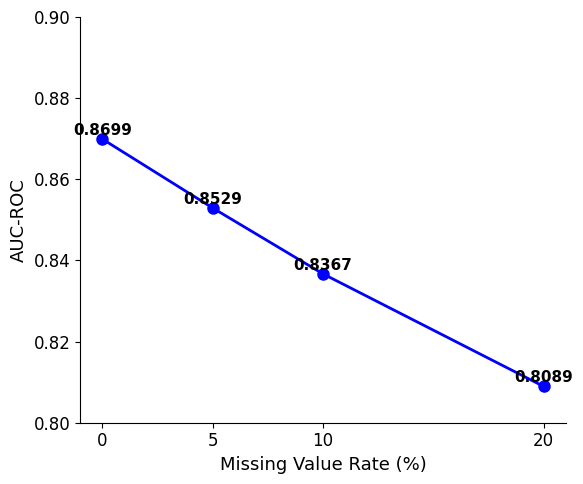

In [7]:
# Figure 10: Missing Values
fig, ax = plt.subplots(figsize=(6, 5))
rates = [0, 5, 10, 20]
auc_means = missing_df['tabpfn_auc_mean'].values
ax.plot(rates, auc_means, color='blue', marker='o', linewidth=2, markersize=8)
ax.set_xlabel('Missing Value Rate (%)', fontsize=13)
ax.set_ylabel('AUC-ROC', fontsize=13)
ax.set_xticks([0, 5, 10, 20])
ax.set_ylim(0.80, 0.90)
ax.tick_params(labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for xi, yi in zip(rates, auc_means):
    ax.text(xi, yi + 0.001, f'{yi:.4f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/figure10_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

## Key findings

- TabPFN’s predictive performance improved as the training subset size increased from 1,000 to 8,000 samples.
- TabPFN consistently outperformed AutoGluon across the evaluated training set sizes.
- The missing value experiment suggests that TabPFN can tolerate incomplete test records under the tested conditions, although predictive performance decreases as the missing value rate increases.